# Numerical Differentiation

There are many ways to perform numerical differentiation— some of which include using Lagrange interpolating polynomials and Richardson extrapolation, as you learned in the lecture. Today, we are going to focus on the central difference method, which you will use extensively moving forward. The approximation to the formula is derived through two standard Taylor series expansions.

Let's look at the two foundational Taylor series expansions around a point $x$ with a step size $\Delta x$:

1. **Forward Taylor Expansion (Step Ahead):**
   $$f(x+\Delta x) = f(x) + \Delta x\frac{df}{dx} + \frac{\Delta x^2}{2}\frac{d^2f}{dx^2} + \frac{\Delta x^3}{6}\frac{d^3f}{dx^3} + O(\Delta x^4)$$

2. **Backward Taylor Expansion (Step Behind):**
   $$f(x-\Delta x) = f(x) - \Delta x\frac{df}{dx} + \frac{\Delta x^2}{2}\frac{d^2f}{dx^2} - \frac{\Delta x^3}{6}\frac{d^3f}{dx^3} + O(\Delta x^4)$$


To derive the Central Difference formula, we **subtract** the backward expansion (2) from the forward expansion (1). 

What happens to each term on the right-hand side during this subtraction?

* **The original function terms:** $f(x) - f(x) = 0$ *(They cancel out)*
* **The first derivative terms:** $\Delta x\frac{df}{dx} - (-\Delta x\frac{df}{dx}) = \mathbf{2\Delta x\frac{df}{dx}}$ *(Since they have opposite signs, they add up)*
* **The second derivative terms:** $\frac{\Delta x^2}{2}\frac{d^2f}{dx^2} - \frac{\Delta x^2}{2}\frac{d^2f}{dx^2} = \mathbf{0}$  
  ***Crucial Point:*** *(Because they have the exact same sign, they cancel each other out completely!)*
* **The third derivative terms:** $\frac{\Delta x^3}{6}\frac{d^3f}{dx^3} - (-\frac{\Delta x^3}{6}\frac{d^3f}{dx^3}) = \mathbf{\frac{\Delta x^3}{3}\frac{d^3f}{dx^3}}$

Putting together what remains after the subtraction, we get:
$$f(x+\Delta x) - f(x-\Delta x) = 2\Delta x\frac{df}{dx} + \frac{\Delta x^3}{3}\frac{d^3f}{dx^3} + ...$$

Since our goal is to approximate the first derivative $\frac{df}{dx}$, let's isolate it by moving the remaining error terms to the other side:
$$2\Delta x\frac{df}{dx} = f(x+\Delta x) - f(x-\Delta x) - \frac{\Delta x^3}{3}\frac{d^3f}{dx^3}$$

Now, we divide both sides of the equation by $2\Delta x$:
$$\frac{df}{dx} = \frac{f(x+\Delta x) - f(x-\Delta x)}{2\Delta x} - \frac{\Delta x^2}{6}\frac{d^3f}{dx^3}$$

Because the leading error term now contains $\Delta x^2$ (since $\Delta x^3 / \Delta x = \Delta x^2$), we can represent the entire remaining truncation error using big-O notation as $O(\Delta x^2)$:
$$\frac{df}{dx} = \frac{f(x+\Delta x) - f(x-\Delta x)}{2\Delta x} + O(\Delta x^2)$$

#### Why is this so much more accurate?
In the Forward or Backward difference methods, the second-derivative error term ($\Delta x^2$) does not cancel out. When divided by $\Delta x$, it leaves a rough error of order $O(\Delta x)$. 

With the Central Difference method, the symmetry of subtracting the two sides **completely eliminates** the second-derivative error before we even divide, allowing us to automatically "jump" to a much higher accuracy of second-order $O(\Delta x^2)$.

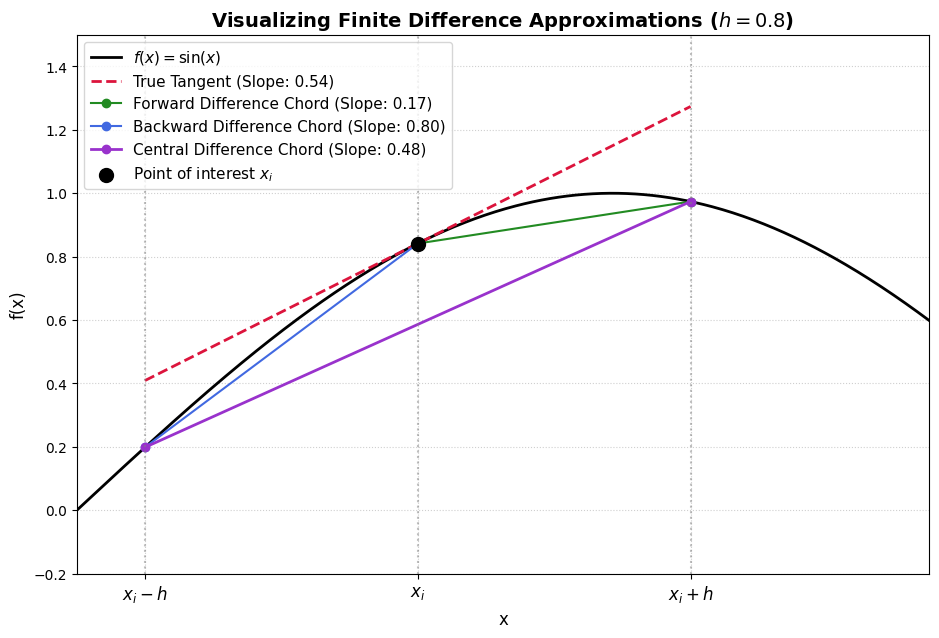

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its exact analytical derivative
def f(x):
    return np.sin(x)

def df_analytical(x):
    return np.cos(x)

# Setup points
x_i = 1.0
h = 0.8

x_forward = x_i + h
x_backward = x_i - h

# Calculate function values at key points
y_i = f(x_i)
y_f = f(x_forward)
y_b = f(x_backward)

# Calculate numerical slopes (derivatives)
slope_forward = (y_f - y_i) / h
slope_backward = (y_i - y_b) / h
slope_central = (y_f - y_b) / (2 * h)
slope_true = df_analytical(x_i)

# Generate dense points for plotting the underlying sine wave
x_dense = np.linspace(0.0, 2.5, 500)
y_dense = f(x_dense)

# Initialize plot
plt.figure(figsize=(11, 7))
plt.plot(x_dense, y_dense, color='black', linewidth=2, label=r'$f(x) = \sin(x)$')

# 1. Plot True Tangent line at x_i
# Equation: y - y_i = slope * (x - x_i) -> y = slope * (x - x_i) + y_i
x_tangent = np.linspace(0.2, 1.8, 100)
y_tangent = slope_true * (x_tangent - x_i) + y_i
plt.plot(x_tangent, y_tangent, color='crimson', linestyle='--', linewidth=2, 
         label=f'True Tangent (Slope: {slope_true:.2f})')

# 2. Plot Forward Difference Chord (from x_i to x_i + h)
plt.plot([x_i, x_forward], [y_i, y_f], color='forestgreen', marker='o', linewidth=1.5,
         label=f'Forward Difference Chord (Slope: {slope_forward:.2f})')

# 3. Plot Backward Difference Chord (from x_i - h to x_i)
plt.plot([x_backward, x_i], [y_b, y_i], color='royalblue', marker='o', linewidth=1.5,
         label=f'Backward Difference Chord (Slope: {slope_backward:.2f})')

# 4. Plot Central Difference Chord (from x_i - h to x_i + h)
plt.plot([x_backward, x_forward], [y_b, y_f], color='darkorchid', marker='o', linewidth=2,
         label=f'Central Difference Chord (Slope: {slope_central:.2f})')

# Highlight the main point of interest
plt.scatter(x_i, y_i, color='black', s=100, zorder=5, label=r'Point of interest $x_i$')

# Annotate x-axis nodes
plt.axvline(x_i, color='grey', linestyle=':', alpha=0.5)
plt.axvline(x_forward, color='grey', linestyle=':', alpha=0.5)
plt.axvline(x_backward, color='grey', linestyle=':', alpha=0.5)
plt.xticks([x_backward, x_i, x_forward], [r'$x_i - h$', r'$x_i$', r'$x_i + h$'], fontsize=12)

# Figure styling
plt.title('Visualizing Finite Difference Approximations ($h = 0.8$)', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.xlim(0.0, 2.5)
plt.ylim(-0.2, 1.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

plt.show()

* **The dashed red line:** The true tangent (slope) of the function at point $x_i$, which equals $0.54$.
* **The green line:** Forward difference (between $x_i$ and $x_{i+1}$).
* **The blue line:** Backward difference (between $x_i$ and $x_{i-1}$).
* **The purple line:** Central difference—we skip $x_i$ itself: despite a relatively large $h$ ($0.8$), it is clearly visible that the purple line is almost parallel to the red line and equals $0.48$!

Thanks to the symmetrical combination we made of the step forward and the step backward, the error terms in the Taylor series **cancel out**, resulting in something very accurate, very fast, and with the exact same computational effort!

---
Here is a small example of what you will be doing in your homework. In Question 2, you will need to run the central difference formula (which appears here) as well as the forward and backward difference formulas. Additionally, you will need to include a (typed) function for the analytical derivative that you calculated yourself (simply type in the formula you got on your paper, which should accept any $x$ value and output the corresponding function value).

In [6]:
import numpy as np

# 1. Define the original function
def f(x):
    """f(x) = x^2 * e^(-0.5x)"""
    return (x**2) * np.exp(-0.5 * x)

# 2. Define the exact analytical derivative
def df_analytical(x):
    """f'(x) = (2x - 0.5 * x^2) * e^(-0.5x)"""
    return (2 * x - 0.5 * (x**2)) * np.exp(-0.5 * x)

# 3. Define the 2nd-order Central Difference numerical derivative
def df_central_numerical(f_func, x, h):
    """
    Approximates the first derivative using the 2nd-order central difference formula.
    Formula: [f(x + h) - f(x - h)] / (2h)
    """
    return (f_func(x + h) - f_func(x - h)) / (2 * h)


def evaluate_differentiation(x_val, h_val):
    """Computes and displays the true value, numerical approximation, and error at a given x."""
    # Compute the true exact derivative
    exact_val = df_analytical(x_val)
    
    # Compute the central difference numerical approximation
    numerical_val = df_central_numerical(f, x_val, h_val)
    
    # Calculate the absolute error
    abs_error = abs(exact_val - numerical_val)
    
    # Print the results neatly
    print(f"Evaluation at x = {x_val} (with h = {h_val}):")
    print(f"Exact Analytical Value   : {exact_val:.8f}")
    print(f"Central Numerical Value  : {numerical_val:.8f}")
    print(f"Absolute Error           : {abs_error:.8e}")
    print()


def main():
    # Setting a step size h
    h_step = 0.1
    
    print("Numerical vs Analytical Differentiation Demonstration")
    print("Function: f(x) = x^2 * e^(-0.5x)")
    print()
    
    # Test the values at x=3 and x=4
    evaluate_differentiation(x_val=3.0, h_val=h_step)
    evaluate_differentiation(x_val=4.0, h_val=h_step)

if __name__ == "__main__":
    main()

Numerical vs Analytical Differentiation Demonstration
Function: f(x) = x^2 * e^(-0.5x)

Evaluation at x = 3.0 (with h = 0.1):
Exact Analytical Value   : 0.33469524
Central Numerical Value  : 0.33483453
Absolute Error           : 1.39287808e-04

Evaluation at x = 4.0 (with h = 0.1):
Exact Analytical Value   : 0.00000000
Central Numerical Value  : 0.00022550
Absolute Error           : 2.25502401e-04



## Optimal step size (h) for 4th order derivative

To understand the analytical part of Question 1 in your homework, let's look at the error magnitude on a log-log scale as a function of the step size ($h$). 

For general knowledge: The reason we use a logarithmic scale for $h$ is that the numbers are extremely small. Using this scale turns each grid square into a different order of magnitude, allowing us to clearly see what is happening in every region regardless of our current scale (if we were to use a linear scale, we wouldn't be able to distinguish, for example, $0.00001$ from $0.1$).

**CLARIFICATION:** Please note that in your homework, you will ***not be required to calculate the minimum $h$ in your code.*** What is presented here is for visualization and understanding purposes only.

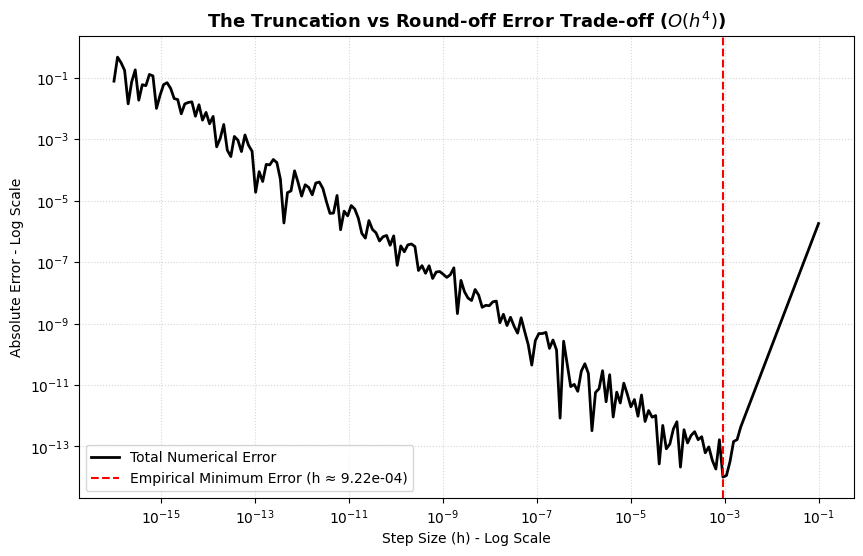

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define function and its true derivative to test
def f(x): return np.sin(x)
def df_true(x): return np.cos(x)

# 2. 4th-order Central Difference formula (from page 5 of lecture notes)
def central_4th(f, x, h):
    return (-f(x + 2*h) + 8*f(x + h) - 8*f(x - h) + f(x - 2*h)) / (12 * h)

x_val = 1.0
# Generate a wide range of step sizes: from 10^-1 to 10^-16
h_values = np.logspace(-16, -1, 200)
errors = []

for h in h_values:
    approx = central_4th(f, x_val, h)
    errors.append(abs(df_true(x_val) - approx))

# Find the h that gave the absolute minimum error in reality
empirical_h_opt = h_values[np.argmin(errors)]

# 3. Plot the classic U-shape trade-off curve
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors, color='black', linewidth=2, label='Total Numerical Error')
plt.axvline(empirical_h_opt, color='red', linestyle='--', 
            label=f'Empirical Minimum Error (h ≈ {empirical_h_opt:.2e})')

plt.title("The Truncation vs Round-off Error Trade-off ($O(h^4)$)", fontsize=13, fontweight='bold')
plt.xlabel("Step Size (h) - Log Scale")
plt.ylabel("Absolute Error - Log Scale")
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.legend()
plt.show()

What do we see here? Exactly what you will prove in your homework! It is the "battle" between $E_{trunc}$ (truncation error) and $E_{round}$ (round-off error). The truncation error is what remains after the terms cancel out in the central difference method, and as we decrease $h$, it decreases as well—until it doesn't. Why? Because we also have the round-off error: the errors in the numerator accumulate as the sum of the absolute values of their coefficients. $h$ becomes so small that the computer starts rounding numbers, which actually increases the error. 

If we add both errors together, differentiate, and set the derivative to zero, we will obtain a single, unique value that represents the minimum error—the sweet spot where $E_{trunc}$ is at its smallest and $E_{round}$ has not yet begun to grow.